3


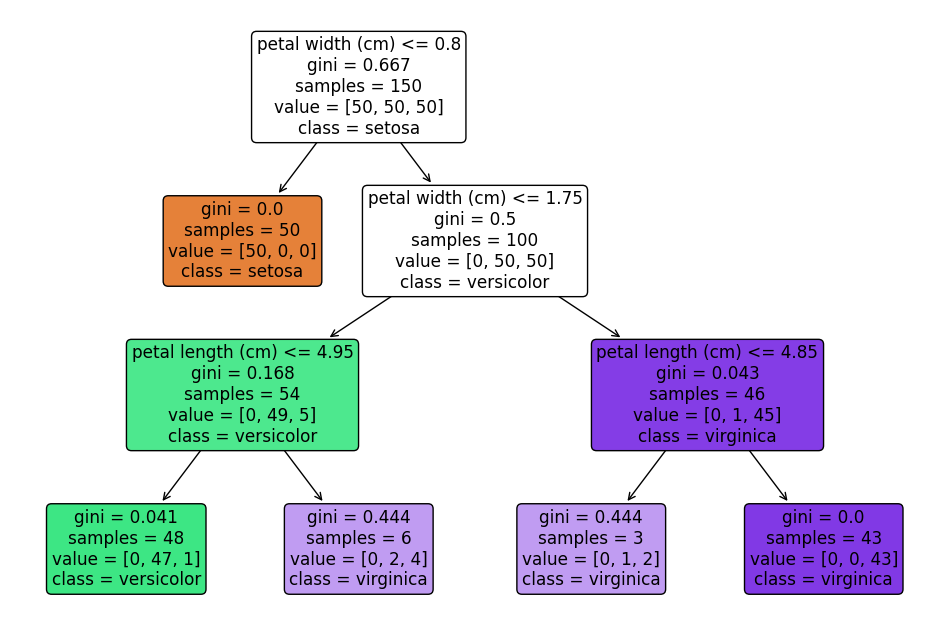

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
X, y = load_iris(return_X_y=True)
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

print(clf.get_depth())  # → 3
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          filled=True,            # 색상 채우기
          feature_names=load_iris().feature_names, 
          class_names=load_iris().target_names, 
          rounded=True)
plt.show()

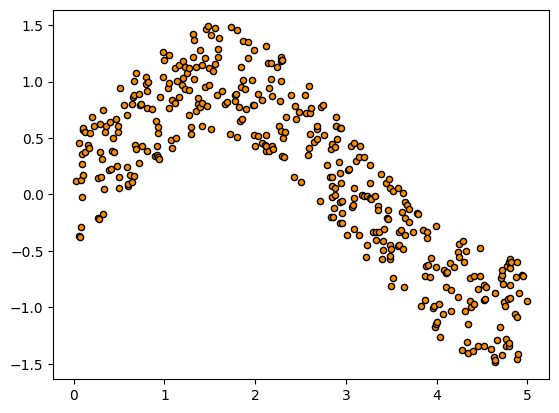

In [4]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

np.random.seed(0)
X=np.sort(5*np.random.rand(400,1),axis=0)
T=np.linspace(0,5,500)[:,np.newaxis]
y=np.sin(X).ravel()

y[::1]+=1*(0.5-np.random.rand(400))
plt.scatter(X,y,s=20,edgecolors="k",c="darkorange",label="data")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings("ignore")

X_train,X_test,Y_train,Y_test= train_test_split(X,y,train_size=0.7)
regr_1=DecisionTreeRegressor(max_depth=2)
regr_2=DecisionTreeRegressor(max_depth=5)

from sklearn.metrics import mean_squared_error,mean_absolute_error
import pandas as pd
import numpy as np

y_1=regr_1.fit(X_train,Y_train).predict(X_test)
y_2=regr_2.fit(X_train,Y_train).predict(X_test)

preds=[y_1,y_2]
weights=["max depth = 2","max depth = 5"]
evls=  ["mse","rmse","mae"]
results=pd.DataFrame(index=weights,columns=evls)
for pred,nm in zip(preds,weights):
    mse=mean_squared_error(Y_test,pred)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(Y_test,pred)

    results.loc[nm]['mse']=mse
    results.loc[nm]['rmse']=rmse
    results.loc[nm]['mae']=mae

results


,mse,rmse,mae
max depth = 2,0.134408,0.366617,0.298704
max depth = 5,0.108988,0.330134,0.275991


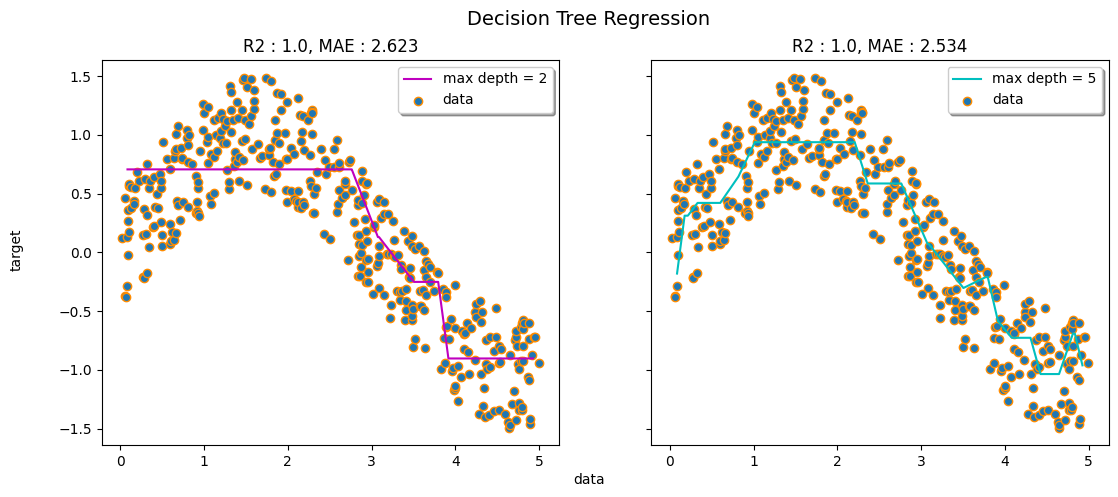

In [6]:
XX_test=np.sort(5*np.random.rand(40,1),axis=0)
regs=[regr_1,regr_2]
depth=["max depth = 2","max depth = 5"]
model_color=['m','c']
fig,axes=plt.subplots(nrows=1,ncols=2,sharey=True,figsize=(13,5))
for i,reg in enumerate(regs):
    pred=reg.fit(X,y).predict(XX_test)
    r2=reg.score(XX_test,pred)
    mae=mean_absolute_error(XX_test,pred)
    axes[i].plot(XX_test,pred,color=model_color[i],label="{}".format(depth[i]))
    axes[i].scatter(X,y,edgecolor='darkorange',label="data")
    axes[i].legend(loc="upper right",ncol=1,fancybox=True,shadow=True)
    axes[i].set_title("R2 : {r}, MAE : {m}".format(r=round(r2,3),m=round(mae,3)))

fig.text(0.5,0.04,"data",ha="center",va="center")
fig.text(0.06,0.5,"target",ha="center",va="center",rotation="vertical")
fig.suptitle("Decision Tree Regression",fontsize=14)
plt.show()